# 从单载波到完整接收机：OFDM 调制与解调入门

这是一份面向新人的、可从头运行的 OFDM 教程。我们不从框图背结论，而是依次观察波形、频谱、时频网格和接收机内部量，理解为什么 OFDM 自然地由 IFFT/FFT 实现。

> 核心主线：**正交子载波 → IFFT/FFT → 帧与时频网格 → STF 同步与频偏估计 → LTF 信道估计 → 单抽头均衡 + pilot 相位跟踪**。

## Goal

运行完本 Notebook 后，你应该能够：

1. 从单个复指数载波出发，解释“在一个 OFDM 符号内正交”的含义；
2. 手工叠加 4 个子载波，并看出它与 IFFT 公式完全一致；
3. 读懂包含 `STF + LTF + header + payload` 的时频网格，以及 pilot 的位置；
4. 用 Schmidl & Cox 度量检测 STF，并从重复半符号的相位差估计载波频偏（CFO）；
5. 用 LTF 估计频率选择性信道，并用 ZF/MMSE 与 pilots 恢复 QPSK 星座。

本例是教学模型，不对应某一特定标准；参数借鉴了常见的 64 点 OFDM 设计。

## Setup

只使用 NumPy、Matplotlib 和 SciPy。固定随机种子保证每次运行得到相同结果。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

rng = np.random.default_rng(20260719)

plt.rcParams.update({
    "figure.figsize": (10, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

BLUE = "#2563EB"
ORANGE = "#EA580C"
GOLD = "#CA8A04"
PINK = "#DB2777"
INK = "#1F2937"
LIGHT = "#CBD5E1"

def qpsk_mod(bits):
    """Gray-like QPSK mapping: [b0,b1] -> ((1-2b0)+j(1-2b1))/sqrt(2)."""
    bits = np.asarray(bits, dtype=int).reshape(-1, 2)
    return ((1 - 2 * bits[:, 0]) + 1j * (1 - 2 * bits[:, 1])) / np.sqrt(2)

def qpsk_demod(symbols):
    symbols = np.asarray(symbols)
    return np.column_stack((symbols.real < 0, symbols.imag < 0)).astype(int).ravel()

def sc_to_bin(subcarriers, n_fft):
    """Convert signed subcarrier numbers (...,-1,0,1,...) to NumPy FFT-bin indices."""
    return np.mod(np.asarray(subcarriers, dtype=int), n_fft)

def ofdm_modulate(freq_bins):
    """Unitary-scaled IFFT: preserves total energy between frequency and time domains."""
    n_fft = len(freq_bins)
    return np.fft.ifft(freq_bins) * np.sqrt(n_fft)

def ofdm_demodulate(time_samples):
    n_fft = len(time_samples)
    return np.fft.fft(time_samples) / np.sqrt(n_fft)

def add_cp(time_samples, n_cp):
    return np.concatenate((time_samples[-n_cp:], time_samples))

def evm_rms(reference, estimate):
    return np.sqrt(np.mean(np.abs(estimate - reference) ** 2) / np.mean(np.abs(reference) ** 2))

def draw_qpsk_reference(ax):
    ideal = qpsk_mod(np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).ravel())
    ax.scatter(ideal.real, ideal.imag, marker="x", s=90, linewidths=2.2,
               color=INK, label="ideal QPSK")
    ax.axhline(0, color=LIGHT, linewidth=1)
    ax.axvline(0, color=LIGHT, linewidth=1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("In-phase")
    ax.set_ylabel("Quadrature")

## Step 1 — 从单载波开始

一个复基带载波可以写为

$$s(t)=A e^{j(2\pi f_c t+\phi)}.$$

实际射频波形取实部。调制的本质是让幅度 $A$、相位 $\phi$ 或频率随信息变化。下面用 4 个 QPSK 相位演示：载波频率不变，但每个符号区间的相位携带了 2 bit 信息。

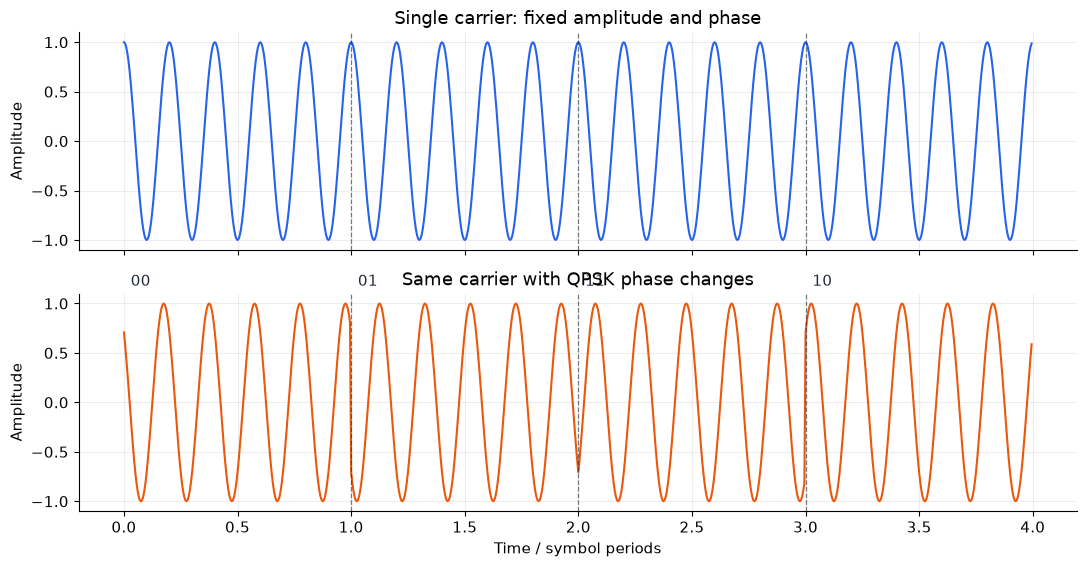

In [2]:
samples_per_symbol = 200
n_symbols_demo = 4
t = np.arange(samples_per_symbol * n_symbols_demo) / samples_per_symbol
carrier_cycles_per_symbol = 5
symbol_phase = np.array([np.pi / 4, 3 * np.pi / 4, -3 * np.pi / 4, -np.pi / 4])
symbol_index = np.minimum((t).astype(int), n_symbols_demo - 1)

plain_carrier = np.cos(2 * np.pi * carrier_cycles_per_symbol * t)
qpsk_carrier = np.cos(2 * np.pi * carrier_cycles_per_symbol * t + symbol_phase[symbol_index])

fig, axes = plt.subplots(2, 1, figsize=(11, 5.8), sharex=True)
axes[0].plot(t, plain_carrier, color=BLUE, linewidth=1.5)
axes[0].set_title("Single carrier: fixed amplitude and phase")
axes[0].set_ylabel("Amplitude")

axes[1].plot(t, qpsk_carrier, color=ORANGE, linewidth=1.5)
axes[1].set_title("Same carrier with QPSK phase changes")
axes[1].set_xlabel("Time / symbol periods")
axes[1].set_ylabel("Amplitude")
for ax in axes:
    for boundary in range(1, n_symbols_demo):
        ax.axvline(boundary, color=INK, linestyle="--", linewidth=0.9, alpha=0.6)
axes[1].text(0.03, 1.18, "00", color=INK)
axes[1].text(1.03, 1.18, "01", color=INK)
axes[1].text(2.03, 1.18, "11", color=INK)
axes[1].text(3.03, 1.18, "10", color=INK)
plt.tight_layout()
plt.show()

### 1.1 从一个载波变成四个正交子载波

让 4 路低速数据分别调制 4 个频率不同的复指数，再把它们相加：

$$x(t)=\sum_{k=0}^{3}X_k e^{j2\pi f_k t}.$$

关键不是“频率不同”这么简单，而是令子载波间隔

$$\Delta f=\frac{1}{T_u},$$

其中 $T_u$ 是有效 OFDM 符号长度。这样任意两个不同子载波在 $[0,T_u)$ 上的内积为零。它们的频谱可以重叠，但在正确的积分/FFT 窗口内仍可完全分离——这就是 **orthogonal** 的含义。

下面刻意给四个子载波设置不同的幅度 $A_k$ 和初始相位 $\phi_k$。它们会明显改变各自波形和叠加结果，但不会破坏由频率间隔 $1/T_u$ 决定的正交性。Gram 矩阵用于验证基函数的正交性；若要观察载波自身的幅度和相位，则需要把叠加波形 `sum_4` 投影回每个基函数——这正是 FFT/相关解调的核心。

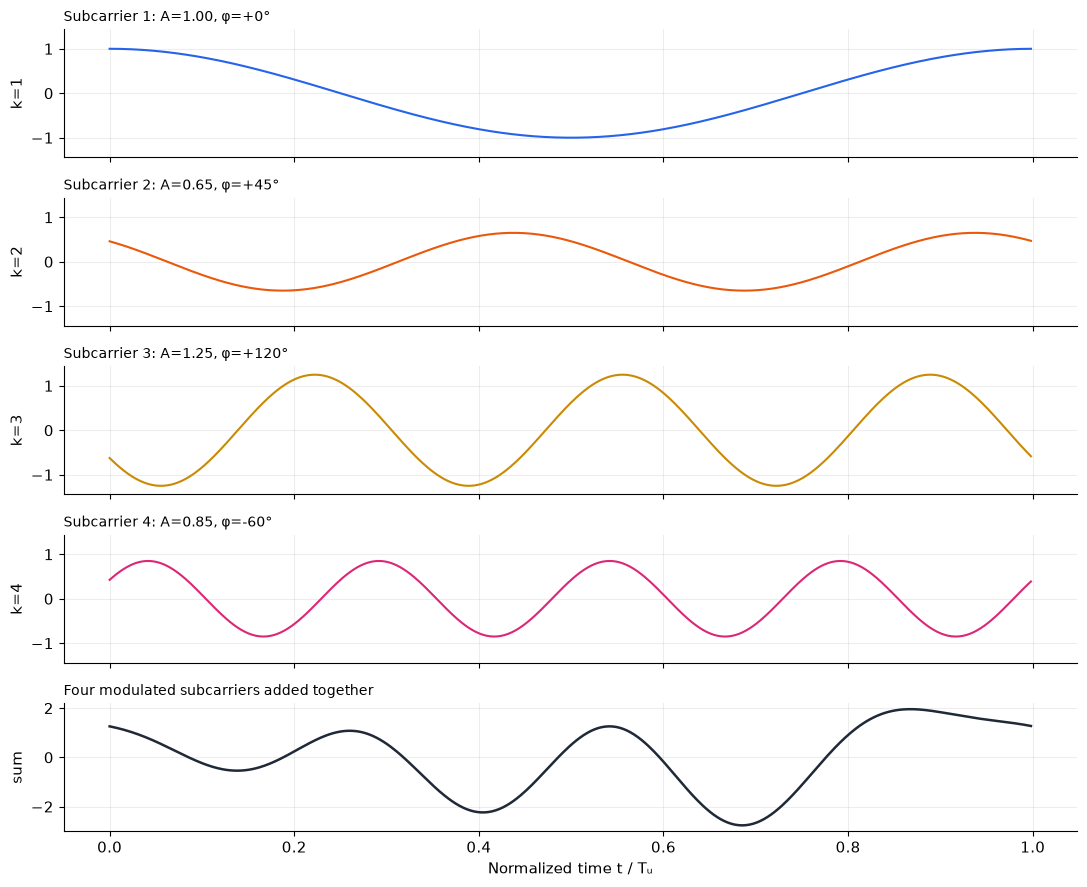

In [3]:
n_dense = 512
t_dense = np.arange(n_dense) / n_dense  # one useful symbol, T_u = 1
subcarrier_numbers_4 = np.array([1, 2, 3, 4])
carrier_amplitudes_4 = np.array([1.00, 0.65, 1.25, 0.85])
carrier_phases_deg_4 = np.array([0.0, 45.0, 120.0, -60.0])
carrier_weights_4 = carrier_amplitudes_4 * np.exp(1j * np.deg2rad(carrier_phases_deg_4))

components_4 = carrier_weights_4[:, None] * np.exp(
    1j * 2 * np.pi * subcarrier_numbers_4[:, None] * t_dense[None, :]
)
sum_4 = components_4.sum(axis=0)

fig, axes = plt.subplots(5, 1, figsize=(11, 9), sharex=True)
carrier_colors_4 = [BLUE, ORANGE, GOLD, PINK]
common_limit = 1.15 * np.max(carrier_amplitudes_4)
for idx, ax in enumerate(axes[:4]):
    ax.plot(t_dense, components_4[idx].real, color=carrier_colors_4[idx], linewidth=1.5)
    ax.set_ylabel(f"k={subcarrier_numbers_4[idx]}")
    ax.set_ylim(-common_limit, common_limit)
    ax.set_title(
        f"Subcarrier {subcarrier_numbers_4[idx]}: "
        f"A={carrier_amplitudes_4[idx]:.2f}, φ={carrier_phases_deg_4[idx]:+.0f}°",
        loc="left", fontsize=10
    )
axes[4].plot(t_dense, sum_4.real, color=INK, linewidth=1.8)
axes[4].set_title("Four modulated subcarriers added together", loc="left", fontsize=10)
axes[4].set_ylabel("sum")
axes[4].set_xlabel("Normalized time t / Tᵤ")
plt.tight_layout()
plt.show()

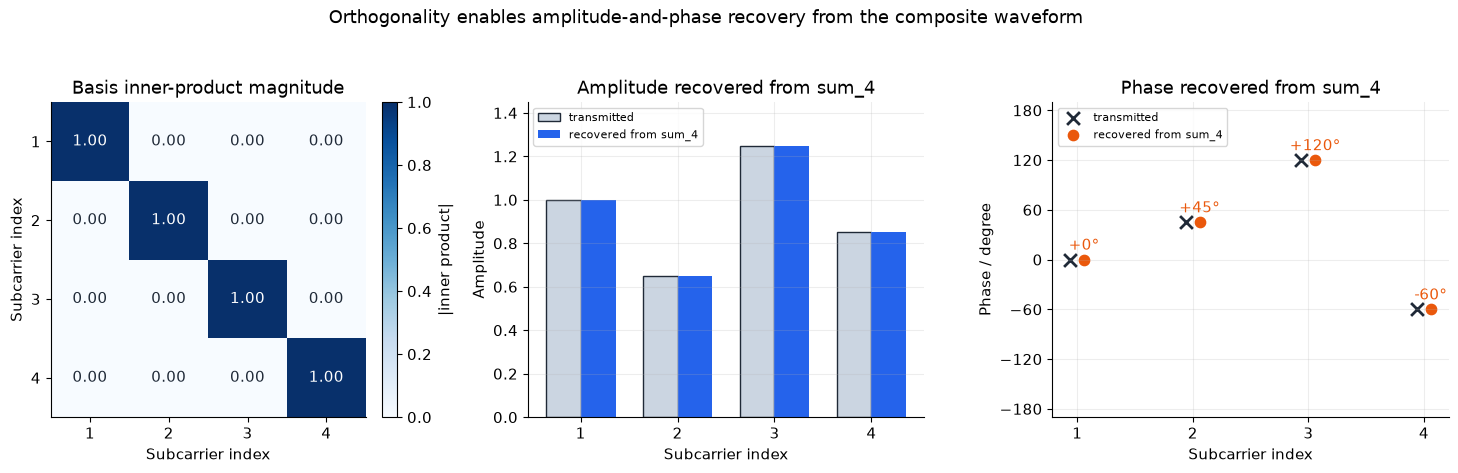

Largest off-diagonal inner product: 1.566e-16
Maximum complex-weight recovery error: 3.140e-16


In [4]:
# 1) Basis-to-basis inner products verify orthogonality.
basis_4 = np.exp(1j * 2 * np.pi * subcarrier_numbers_4[:, None] * t_dense[None, :])
gram_4 = basis_4 @ basis_4.conj().T / n_dense
gram_magnitude = np.abs(gram_4)

# 2) Project the composite waveform back onto every basis function.
# This correlation recovers each complex carrier weight: amplitude AND phase.
recovered_weights_4 = basis_4.conj() @ sum_4 / n_dense
recovered_amplitudes_4 = np.abs(recovered_weights_4)
recovered_phases_deg_4 = np.rad2deg(np.angle(recovered_weights_4))

fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.8))

# Left: the orthogonality matrix belongs to the basis functions, not to sum_4.
magnitude_image = axes[0].imshow(gram_magnitude, cmap="Blues", vmin=0, vmax=1)
axes[0].set_title("Basis inner-product magnitude")
for row in range(4):
    for col in range(4):
        axes[0].text(col, row, f"{gram_magnitude[row, col]:.2f}",
                     ha="center", va="center",
                     color="white" if gram_magnitude[row, col] > 0.5 else INK)
axes[0].set_xticks(range(4), labels=subcarrier_numbers_4)
axes[0].set_yticks(range(4), labels=subcarrier_numbers_4)
axes[0].set_xlabel("Subcarrier index")
axes[0].set_ylabel("Subcarrier index")
axes[0].grid(False)
fig.colorbar(magnitude_image, ax=axes[0], label="|inner product|", fraction=0.046, pad=0.04)

# Middle: amplitude recovered from the summed waveform.
bar_width = 0.36
x_positions = np.arange(4)
axes[1].bar(x_positions - bar_width / 2, carrier_amplitudes_4, bar_width,
            color=LIGHT, edgecolor=INK, label="transmitted")
axes[1].bar(x_positions + bar_width / 2, recovered_amplitudes_4, bar_width,
            color=BLUE, label="recovered from sum_4")
axes[1].set_xticks(x_positions, labels=subcarrier_numbers_4)
axes[1].set_ylim(0, 1.45)
axes[1].set_xlabel("Subcarrier index")
axes[1].set_ylabel("Amplitude")
axes[1].set_title("Amplitude recovered from sum_4")
axes[1].legend(fontsize=8)

# Right: phase recovered from the same complex projections.
axes[2].scatter(x_positions - 0.06, carrier_phases_deg_4, marker="x", s=85,
                linewidths=2, color=INK, label="transmitted")
axes[2].scatter(x_positions + 0.06, recovered_phases_deg_4, marker="o", s=55,
                color=ORANGE, label="recovered from sum_4")
for idx, phase in enumerate(recovered_phases_deg_4):
    axes[2].text(idx + 0.06, phase + 12, f"{phase:+.0f}°", ha="center", color=ORANGE)
axes[2].set_xticks(x_positions, labels=subcarrier_numbers_4)
axes[2].set_yticks(np.arange(-180, 181, 60))
axes[2].set_ylim(-190, 190)
axes[2].set_xlabel("Subcarrier index")
axes[2].set_ylabel("Phase / degree")
axes[2].set_title("Phase recovered from sum_4")
axes[2].legend(fontsize=8)

fig.suptitle("Orthogonality enables amplitude-and-phase recovery from the composite waveform")
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

off_diagonal_mask = ~np.eye(4, dtype=bool)
largest_cross_inner_product = np.max(gram_magnitude[off_diagonal_mask])
recovery_error = np.max(np.abs(recovered_weights_4 - carrier_weights_4))
print(f"Largest off-diagonal inner product: {largest_cross_inner_product:.3e}")
print(f"Maximum complex-weight recovery error: {recovery_error:.3e}")

## Step 2 — 为什么 IFFT/FFT 天生适合 OFDM

把一个符号均匀采样为 $N$ 点，刚才的叠加式变为

$$x[n]=\frac{1}{N}\sum_{k=0}^{N-1}X[k]e^{j2\pi kn/N},\quad n=0,\ldots,N-1.$$

这正是 IDFT（工程中由 IFFT 快速计算）的定义。接收端反过来做

$$\hat X[k]=\sum_{n=0}^{N-1}x[n]e^{-j2\pi kn/N},$$

也就是 FFT。于是：

- **频域的一个数组元素** = 一路子载波上的一个复调制符号；
- **一次 IFFT** = 同时生成所有子载波并完成叠加；
- **一次 FFT** = 同时与所有正交子载波做相关，拆回各路符号。

NumPy 的 `ifft` 自带 $1/N$，下面直接验证手工求和与 IFFT 的一致性。

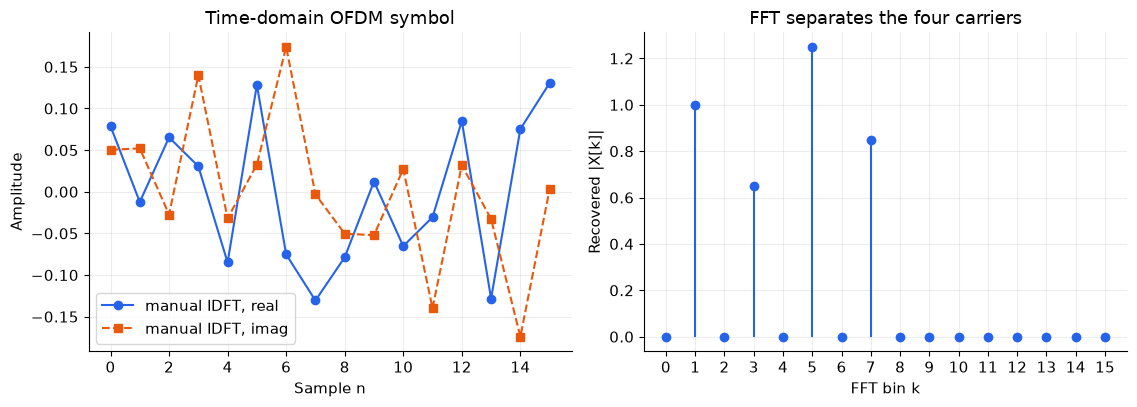

manual IDFT vs np.fft.ifft max error: 3.838e-16
FFT round-trip max error:             2.220e-16


In [5]:
n_fft_small = 16
occupied_bins_small = np.array([1, 3, 5, 7])
X_small = np.zeros(n_fft_small, dtype=complex)
X_small[occupied_bins_small] = carrier_weights_4

n = np.arange(n_fft_small)
k = np.arange(n_fft_small)
idft_matrix = np.exp(1j * 2 * np.pi * n[:, None] * k[None, :] / n_fft_small)
x_manual = idft_matrix @ X_small / n_fft_small
x_ifft = np.fft.ifft(X_small)
X_recovered = np.fft.fft(x_ifft)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
axes[0].plot(n, x_manual.real, "o-", color=BLUE, label="manual IDFT, real")
axes[0].plot(n, x_manual.imag, "s--", color=ORANGE, label="manual IDFT, imag")
axes[0].set_title("Time-domain OFDM symbol")
axes[0].set_xlabel("Sample n")
axes[0].set_ylabel("Amplitude")
axes[0].legend()

markerline, stemlines, baseline = axes[1].stem(k, np.abs(X_recovered), basefmt=" ")
plt.setp(markerline, color=BLUE)
plt.setp(stemlines, color=BLUE)
axes[1].set_title("FFT separates the four carriers")
axes[1].set_xlabel("FFT bin k")
axes[1].set_ylabel("Recovered |X[k]|")
axes[1].set_xticks(k)
plt.tight_layout()
plt.show()

print(f"manual IDFT vs np.fft.ifft max error: {np.max(np.abs(x_manual - x_ifft)):.3e}")
print(f"FFT round-trip max error:             {np.max(np.abs(X_recovered - X_small)):.3e}")

### 2.1 一个容易混淆的点：子载波并不是四条互不接触的窄带滤波器

有限时长的正弦信号具有 sinc 形频谱，邻近子载波的旁瓣彼此重叠。正交性保证的是：在其他子载波的中心频率（FFT 采样点）上，旁瓣恰好过零。因此只要定时窗口、频率栅格和采样时钟正确，FFT 就能无串扰地分离它们；这些条件被破坏时会出现 ICI（inter-carrier interference）。

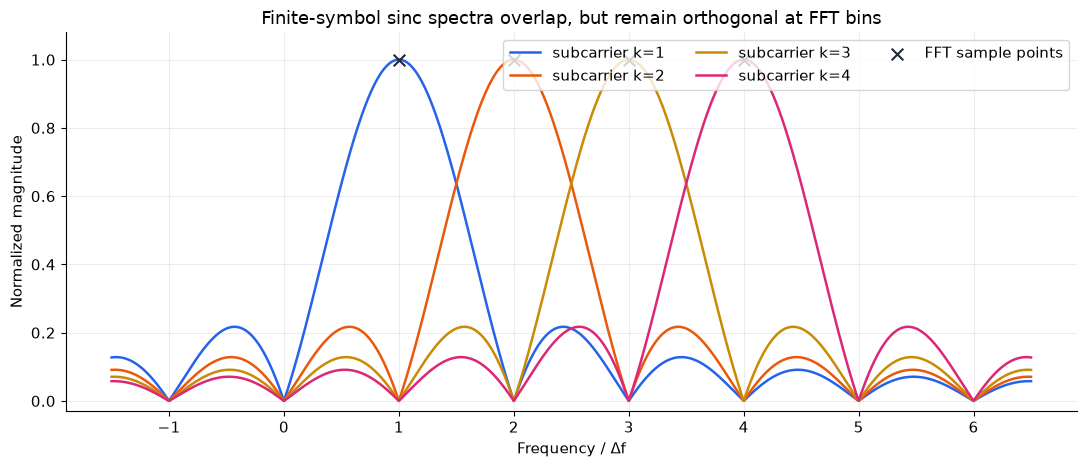

In [6]:
# Show overlapping sinc spectra of four finite-duration carriers.
frequency_axis = np.linspace(-1.5, 6.5, 1800)
fig, ax = plt.subplots(figsize=(11, 4.8))
colors = [BLUE, ORANGE, GOLD, PINK]
for sc, color in zip(subcarrier_numbers_4, colors):
    spectrum = np.abs(np.sinc(frequency_axis - sc))
    ax.plot(frequency_axis, spectrum, color=color, linewidth=1.8, label=f"subcarrier k={sc}")
ax.scatter(subcarrier_numbers_4, np.ones(4), color=INK, marker="x", s=70, zorder=5,
           label="FFT sample points")
ax.set_title("Finite-symbol sinc spectra overlap, but remain orthogonal at FFT bins")
ax.set_xlabel("Frequency / Δf")
ax.set_ylabel("Normalized magnitude")
ax.set_ylim(-0.03, 1.08)
ax.legend(ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

## Step 3 — 时频网格与一帧 OFDM

OFDM 发射机通常先在二维网格上安排资源：

- 横轴是子载波（频率）；
- 纵轴是连续的 OFDM 符号（时间）；
- 每个格点是一个复数 resource element；
- DC 与边缘 guard 子载波留空；
- STF/LTF 放已知训练序列；
- header 与 payload 的大部分格点放数据，同时保留少量已知 pilots。

本例使用 64 点 FFT、16 点循环前缀（CP）、52 个活动子载波。帧结构为：

`STF (无 CP) | LTF | header | payload × 6`

其中 LTF、header 和 payload 都带 CP。CP 是有效符号尾部的复制；只要 CP 不短于信道记忆，它就把线性卷积在 FFT 窗内变为循环卷积，使每个子载波近似只需一个复数系数均衡。

In [7]:
N_FFT = 64
N_CP = 16
active_sc = np.r_[np.arange(-26, 0), np.arange(1, 27)]
pilot_sc = np.array([-21, -7, 7, 21])
data_sc = np.array([sc for sc in active_sc if sc not in set(pilot_sc)])
stf_sc = np.array([sc for sc in active_sc if sc % 2 == 0])  # even k -> N/2 repetition

n_payload_symbols = 6
symbol_names = ["STF", "LTF", "header"] + [f"payload {idx + 1}" for idx in range(n_payload_symbols)]
n_grid_symbols = len(symbol_names)
frequency_grid = np.zeros((n_grid_symbols, N_FFT), dtype=complex)

# Known STF: only even-numbered active subcarriers are occupied.
stf_bits = rng.integers(0, 2, 2 * len(stf_sc))
frequency_grid[0, sc_to_bin(stf_sc, N_FFT)] = qpsk_mod(stf_bits)

# Known LTF: BPSK on every active subcarrier.
ltf_sequence = rng.choice([-1.0, 1.0], size=len(active_sc)).astype(complex)
frequency_grid[1, sc_to_bin(active_sc, N_FFT)] = ltf_sequence

# Header and payload: QPSK data + four known BPSK pilots per symbol.
pilot_base = np.array([1, 1, 1, -1], dtype=complex)
pilot_polarities = np.array([1, 1, -1, 1, -1, -1, 1])
pilot_reference = []
tx_bits_by_symbol = []

for grid_row in range(2, n_grid_symbols):
    bits = rng.integers(0, 2, 2 * len(data_sc))
    frequency_grid[grid_row, sc_to_bin(data_sc, N_FFT)] = qpsk_mod(bits)
    pilots = pilot_base * pilot_polarities[grid_row - 2]
    frequency_grid[grid_row, sc_to_bin(pilot_sc, N_FFT)] = pilots
    tx_bits_by_symbol.append(bits)
    pilot_reference.append(pilots)

pilot_reference = np.asarray(pilot_reference)
tx_bits_all = np.concatenate(tx_bits_by_symbol)

print(f"FFT size: {N_FFT}, CP: {N_CP}, active: {len(active_sc)}, data: {len(data_sc)}, pilots: {len(pilot_sc)}")
print(f"Header + payload carry {len(tx_bits_all)} coded-example bits in this frame.")

FFT size: 64, CP: 16, active: 52, data: 48, pilots: 4
Header + payload carry 672 coded-example bits in this frame.


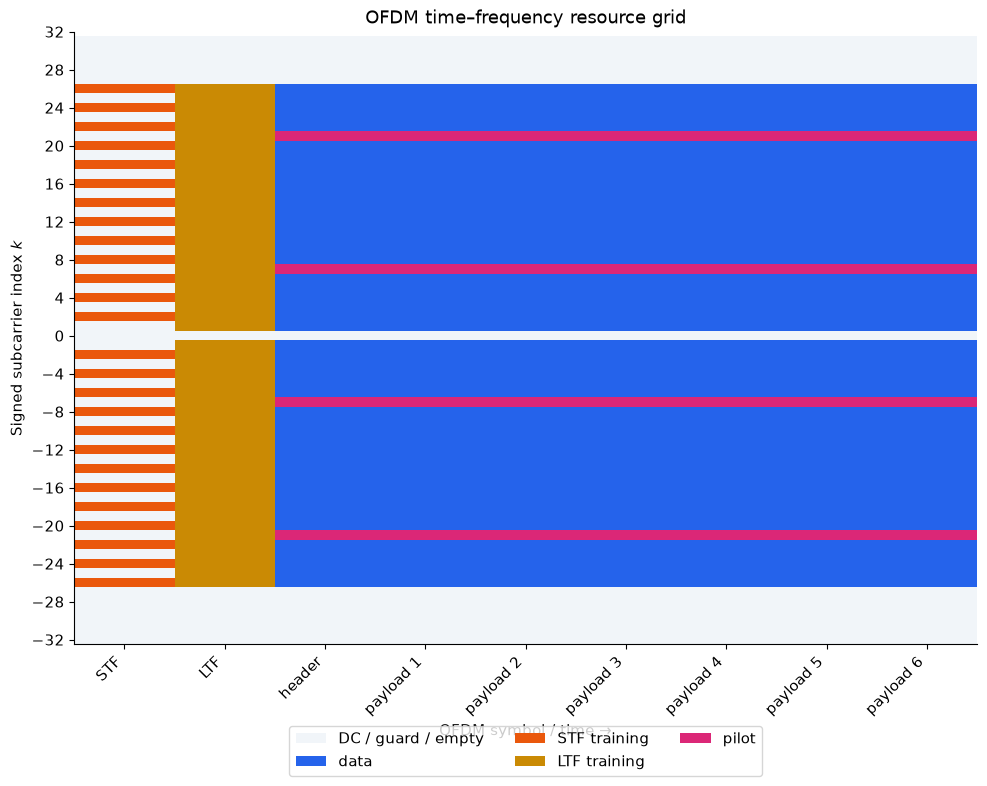

In [17]:
# Shift subcarriers to signed order, then transpose:
# rows -> subcarriers, columns -> OFDM symbols
grid_nr = np.fft.fftshift(resource_kind, axes=1).T

fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(
    grid_nr,
    aspect="auto",
    interpolation="nearest",
    cmap=grid_cmap,
    vmin=0,
    vmax=4,
    origin="lower",
    extent=[
        -0.5,
        n_grid_symbols - 0.5,
        -N_FFT / 2 - 0.5,
        N_FFT / 2 - 0.5,
    ],
)

# Horizontal axis: OFDM symbols / time
ax.set_xticks(np.arange(n_grid_symbols))
ax.set_xticklabels(symbol_names, rotation=45, ha="right")

# Vertical axis: signed subcarrier index
ax.set_yticks(np.arange(-N_FFT // 2, N_FFT // 2 + 1, 4))

ax.set_xlabel("OFDM symbol / time →")
ax.set_ylabel("Signed subcarrier index $k$")
ax.set_title("OFDM time–frequency resource grid")
ax.grid(False)

legend_items = [
    Patch(facecolor="#F1F5F9", label="DC / guard / empty"),
    Patch(facecolor=BLUE, label="data"),
    Patch(facecolor=ORANGE, label="STF training"),
    Patch(facecolor=GOLD, label="LTF training"),
    Patch(facecolor=PINK, label="pilot"),
]

ax.legend(
    handles=legend_items,
    ncol=3,
    bbox_to_anchor=(0.5, -0.12),
    loc="upper center",
)

plt.tight_layout()
plt.show()

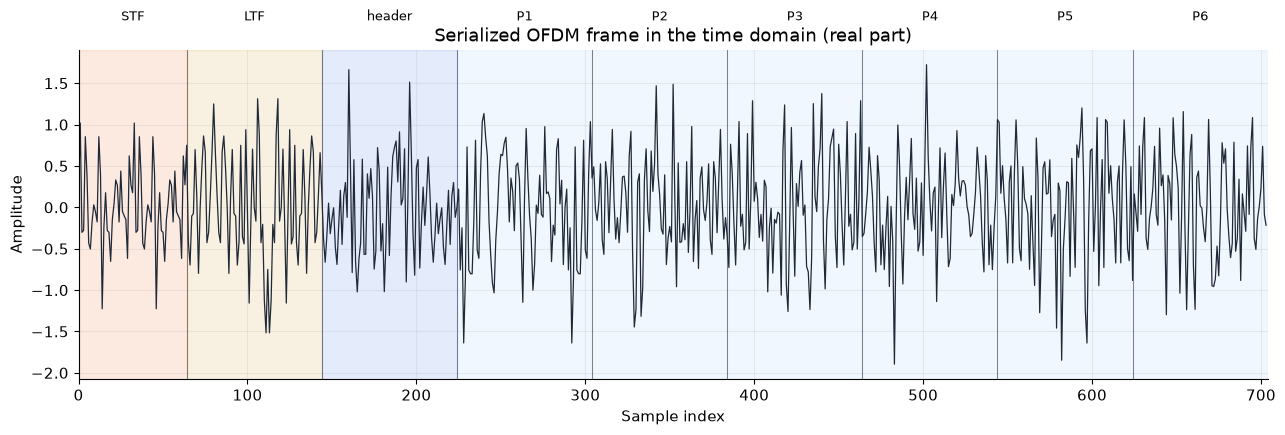

Field lengths in samples: {'STF': np.int64(64), 'LTF': np.int64(80), 'header': np.int64(80), 'payload 1': np.int64(80), 'payload 2': np.int64(80), 'payload 3': np.int64(80), 'payload 4': np.int64(80), 'payload 5': np.int64(80), 'payload 6': np.int64(80)}


In [9]:
# Convert every row of the grid to time samples and serialize the frame.
time_symbols = [ofdm_modulate(frequency_grid[row]) for row in range(n_grid_symbols)]
frame_fields = [time_symbols[0]] + [add_cp(time_symbols[row], N_CP) for row in range(1, n_grid_symbols)]
field_lengths = np.array([len(field) for field in frame_fields])
field_starts = np.r_[0, np.cumsum(field_lengths)[:-1]]
tx_frame = np.concatenate(frame_fields)

fig, ax = plt.subplots(figsize=(13, 4.5))
field_colors = [ORANGE, GOLD, BLUE] + ["#93C5FD"] * n_payload_symbols
for name, start, length, color in zip(symbol_names, field_starts, field_lengths, field_colors):
    ax.axvspan(start, start + length, color=color, alpha=0.12)
    ax.axvline(start, color=INK, linewidth=0.7, alpha=0.55)
    ax.text(start + length / 2, 1.08, name.replace("payload ", "P"), ha="center", va="bottom",
            transform=ax.get_xaxis_transform(), fontsize=9)
ax.plot(tx_frame.real, color=INK, linewidth=0.9)
ax.set_title("Serialized OFDM frame in the time domain (real part)")
ax.set_xlabel("Sample index")
ax.set_ylabel("Amplitude")
ax.set_xlim(0, len(tx_frame))
plt.tight_layout()
plt.show()

print("Field lengths in samples:", dict(zip(symbol_names, field_lengths)))

### 3.1 为什么“间隔子载波排列”会产生重复的 STF

本例 STF 只占用偶数编号子载波。令 $N=64$、$L=N/2=32$，则

$$x[n+L]=\frac{1}{N}\sum_{k\ \mathrm{even}}X[k]e^{j2\pi k(n+N/2)/N}
=\frac{1}{N}\sum_{k\ \mathrm{even}}X[k]e^{j2\pi kn/N}e^{j\pi k}=x[n],$$

因为偶数 $k$ 满足 $e^{j\pi k}=1$。所以 STF 的前 32 点与后 32 点完全相同。更一般地，每隔 $D$ 个子载波放一个值，会在时域产生长度 $N/D$ 的周期重复结构。

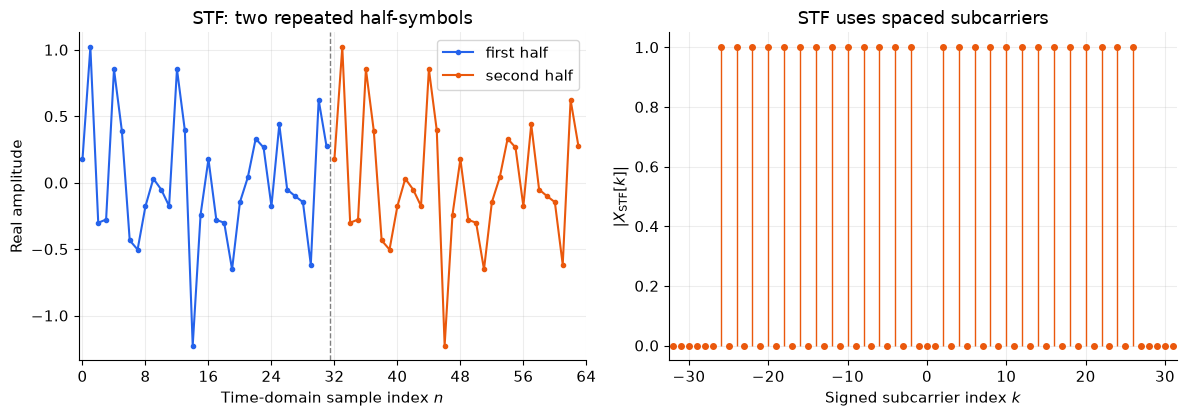

Maximum difference between STF halves: 0.000e+00


In [18]:
stf_time = time_symbols[0]
half = N_FFT // 2
repeat_error = np.max(np.abs(stf_time[:half] - stf_time[half:]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

# Plot the two repeated halves side by side
axes[0].plot(
    np.arange(half),
    stf_time[:half].real,
    "o-",
    markersize=3,
    color=BLUE,
    label="first half",
)

axes[0].plot(
    np.arange(half, N_FFT),
    stf_time[half:].real,
    "o-",
    markersize=3,
    color=ORANGE,
    label="second half",
)

# Mark the boundary between the two halves
axes[0].axvline(half - 0.5, color="gray", linestyle="--", linewidth=1)

axes[0].set_title("STF: two repeated half-symbols")
axes[0].set_xlabel("Time-domain sample index $n$")
axes[0].set_ylabel("Real amplitude")
axes[0].set_xlim(-0.5, N_FFT - 0.5)
axes[0].set_xticks(np.arange(0, N_FFT + 1, 8))
axes[0].legend()

# Frequency-domain STF
stf_shifted = np.fft.fftshift(frequency_grid[0])
signed_bins = np.arange(-N_FFT // 2, N_FFT // 2)

markerline, stemlines, baseline = axes[1].stem(
    signed_bins,
    np.abs(stf_shifted),
    basefmt=" ",
)

plt.setp(markerline, color=ORANGE, markersize=4)
plt.setp(stemlines, color=ORANGE, linewidth=1)

axes[1].set_title("STF uses spaced subcarriers")
axes[1].set_xlabel("Signed subcarrier index $k$")
axes[1].set_ylabel(r"$|X_{\mathrm{STF}}[k]|$")
axes[1].set_xlim(-N_FFT // 2 - 0.5, N_FFT // 2 - 0.5)

plt.tight_layout()
plt.show()

print(f"Maximum difference between STF halves: {repeat_error:.3e}")

## Step 4 — 接收机同步：Schmidl & Cox

接收机看到的并不是从第 0 点整齐开始的帧，还会遇到噪声、频率选择性多径和本振频偏。下面加入：

- 43 点未知到达延迟；
- 3 路多径信道（最大延迟 5 点，小于 16 点 CP）；
- $0.18\Delta f$ 的归一化 CFO；
- 每个后续符号缓慢变化的公共相位，用来说明 pilots 的作用；
- 22 dB AWGN。

对长度为 $2L$、两半重复的 STF，Schmidl & Cox 定义

$$P(d)=\sum_{m=0}^{L-1}r^*[d+m]r[d+m+L],$$
$$R(d)=\sum_{m=0}^{L-1}|r[d+m+L]|^2,$$
$$M(d)=\frac{|P(d)|^2}{R^2(d)+\epsilon}.$$

当窗口覆盖重复结构时，$M(d)$ 接近 1。若 CFO 用“子载波间隔的倍数” $\varepsilon$ 表示，则

$$\hat\varepsilon=\frac{N}{2\pi L}\angle P(d).$$

本例 $L=N/2$，所以 $\hat\varepsilon=\angle P/\pi$。这个估计的无模糊范围约为 $|\varepsilon|<N/(2L)=1$ 个子载波间隔。

In [11]:
# Add a gentle per-field common phase drift; pilots will estimate it later.
field_phase = np.array([0.0, 0.0, 0.08] + [0.08 + 0.07 * (idx + 1) for idx in range(n_payload_symbols)])
phase_profile = np.zeros(len(tx_frame))
for phase, start, length in zip(field_phase, field_starts, field_lengths):
    phase_profile[start:start + length] = phase
tx_with_phase = tx_frame * np.exp(1j * phase_profile)

# A sparse frequency-selective channel. Its memory (5 samples) is shorter than the CP (16).
channel_taps = np.zeros(6, dtype=complex)
channel_taps[[0, 2, 5]] = [1.0, 0.45 * np.exp(1j * 0.7), 0.25 * np.exp(-1j * 1.1)]
channel_taps /= np.linalg.norm(channel_taps)

timing_offset_true = 43
cfo_true = 0.18  # normalized by subcarrier spacing Δf
snr_db = 22.0

through_channel = np.convolve(tx_with_phase, channel_taps)
rx_clean = np.concatenate((np.zeros(timing_offset_true, dtype=complex), through_channel))
sample_index = np.arange(len(rx_clean))
rx_with_cfo = rx_clean * np.exp(1j * 2 * np.pi * cfo_true * sample_index / N_FFT)

signal_power = np.mean(np.abs(through_channel) ** 2)
noise_variance = signal_power / (10 ** (snr_db / 10))
noise = np.sqrt(noise_variance / 2) * (
    rng.standard_normal(len(rx_with_cfo)) + 1j * rng.standard_normal(len(rx_with_cfo))
)
rx = rx_with_cfo + noise

print(f"True timing offset = {timing_offset_true} samples")
print(f"True CFO = {cfo_true:.3f} × Δf, SNR = {snr_db:.1f} dB")
print("Channel taps:", np.round(channel_taps, 3))

True timing offset = 43 samples
True CFO = 0.180 × Δf, SNR = 22.0 dB
Channel taps: [0.889+0.j    0.   +0.j    0.306+0.258j 0.   +0.j    0.   +0.j
 0.101-0.198j]


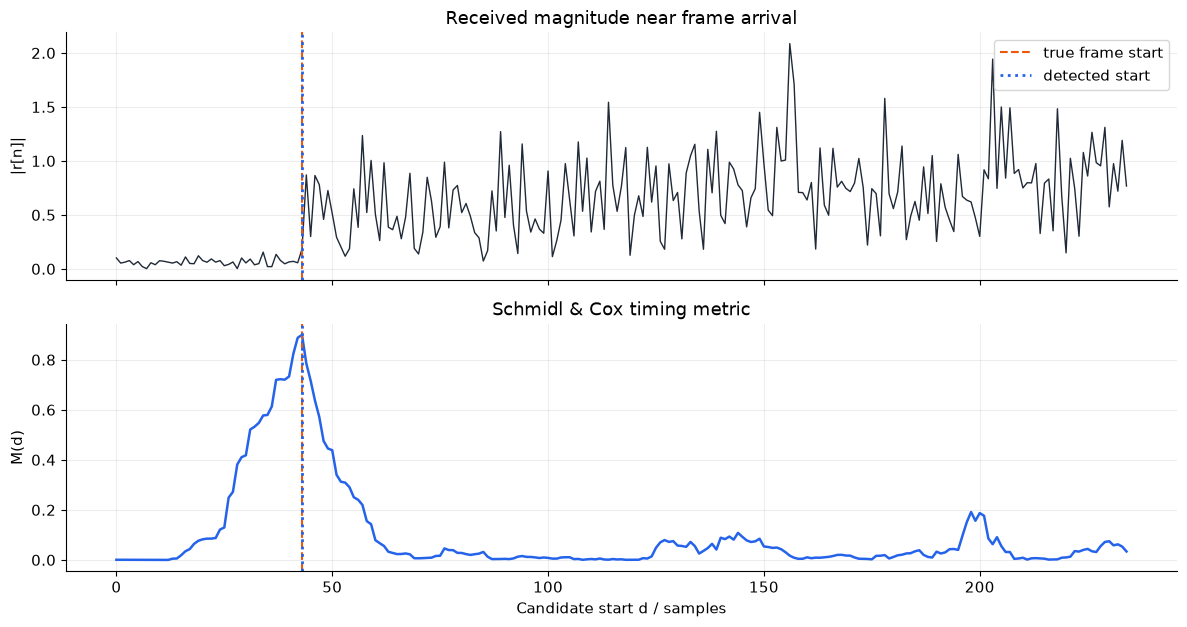

Detected timing = 43 (error +0 samples)
Estimated CFO   = 0.1825 × Δf (error +0.0025)


In [12]:
L_SYNC = N_FFT // 2
n_candidates = len(rx) - 2 * L_SYNC + 1
P_metric = np.zeros(n_candidates, dtype=complex)
R_metric = np.zeros(n_candidates)

for d in range(n_candidates):
    first_half = rx[d:d + L_SYNC]
    second_half = rx[d + L_SYNC:d + 2 * L_SYNC]
    P_metric[d] = np.vdot(first_half, second_half)
    R_metric[d] = np.sum(np.abs(second_half) ** 2)

M_metric = np.abs(P_metric) ** 2 / (R_metric ** 2 + 1e-15)
# Suppress meaningless ratios in noise-only regions.
M_metric[R_metric < 0.08 * np.max(R_metric)] = 0.0
search_stop = min(timing_offset_true + 3 * N_FFT, len(M_metric))
timing_offset_hat = int(np.argmax(M_metric[:search_stop]))
cfo_hat = (N_FFT / (2 * np.pi * L_SYNC)) * np.angle(P_metric[timing_offset_hat])

view_stop = timing_offset_true + 3 * N_FFT
fig, axes = plt.subplots(2, 1, figsize=(12, 6.4), sharex=True)
axes[0].plot(np.abs(rx[:view_stop]), color=INK, linewidth=1)
axes[0].axvline(timing_offset_true, color=ORANGE, linestyle="--", label="true frame start")
axes[0].axvline(timing_offset_hat, color=BLUE, linestyle=":", linewidth=2, label="detected start")
axes[0].set_title("Received magnitude near frame arrival")
axes[0].set_ylabel("|r[n]|")
axes[0].legend()

axes[1].plot(M_metric[:view_stop], color=BLUE, linewidth=1.8)
axes[1].axvline(timing_offset_true, color=ORANGE, linestyle="--")
axes[1].axvline(timing_offset_hat, color=BLUE, linestyle=":", linewidth=2)
axes[1].set_title("Schmidl & Cox timing metric")
axes[1].set_xlabel("Candidate start d / samples")
axes[1].set_ylabel("M(d)")
plt.tight_layout()
plt.show()

print(f"Detected timing = {timing_offset_hat} (error {timing_offset_hat - timing_offset_true:+d} samples)")
print(f"Estimated CFO   = {cfo_hat:.4f} × Δf (error {cfo_hat - cfo_true:+.4f})")

实际系统常看到一个平台而非针尖峰值：循环前缀、重复次数和多径都会改变度量形状。因此工程实现通常还会结合门限的首个越过点、能量检测、平台中心/边缘选择，或用 LTF 再精同步。这里选择搜索区内最大值，目的是清楚展示重复 STF 提供的相关峰与 CFO 相位。

接着用 $\hat\varepsilon$ 对整段接收信号乘上反向相位旋转。

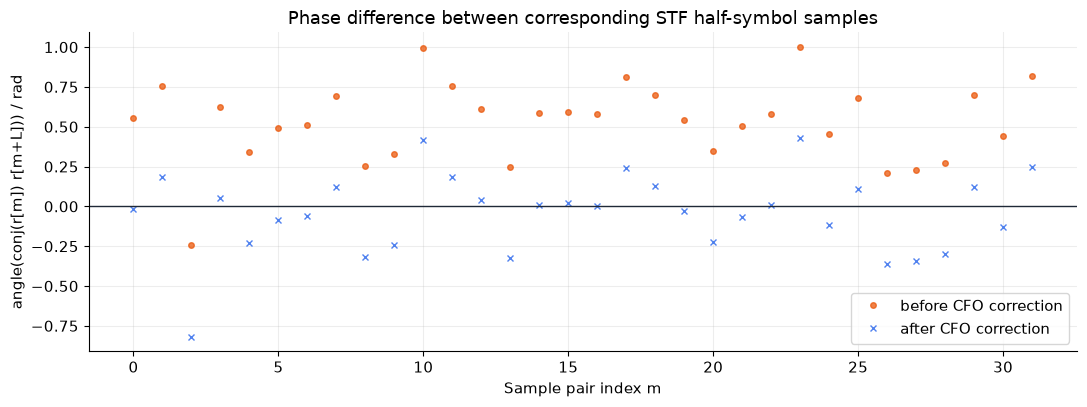

In [13]:
rx_cfo_corrected = rx * np.exp(-1j * 2 * np.pi * cfo_hat * np.arange(len(rx)) / N_FFT)

# Compare the phase relation between the two STF halves before and after CFO correction.
stf_rx_before = rx[timing_offset_hat:timing_offset_hat + N_FFT]
stf_rx_after = rx_cfo_corrected[timing_offset_hat:timing_offset_hat + N_FFT]
phase_before = np.angle(np.conj(stf_rx_before[:L_SYNC]) * stf_rx_before[L_SYNC:])
phase_after = np.angle(np.conj(stf_rx_after[:L_SYNC]) * stf_rx_after[L_SYNC:])

fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(phase_before, "o", markersize=4, color=ORANGE, alpha=0.75, label="before CFO correction")
ax.plot(phase_after, "x", markersize=5, color=BLUE, alpha=0.8, label="after CFO correction")
ax.axhline(0, color=INK, linewidth=1)
ax.set_title("Phase difference between corresponding STF half-symbol samples")
ax.set_xlabel("Sample pair index m")
ax.set_ylabel("angle(conj(r[m]) r[m+L])) / rad")
ax.legend()
plt.tight_layout()
plt.show()

## Step 5 — LTF 信道估计与频域均衡

去掉 CP 并 FFT 后，在 CP 足够长且同步正确时，每个活动子载波满足

$$Y[k]=H[k]X[k]+W[k].$$

LTF 的 $X_{LTF}[k]$ 已知，因此最直接的 LS 信道估计是

$$\hat H[k]=\frac{Y_{LTF}[k]}{X_{LTF}[k]}.$$

之后每个子载波都只需一个复数乘法：

- ZF：$\hat X_{ZF}[k]=Y[k]/\hat H[k]$，能消除信道，但深衰落处会放大噪声；
- MMSE：$\hat X_{MMSE}[k]=Y[k]\hat H^*[k]/(|\hat H[k]|^2+\sigma_w^2)$，以少量偏差换取更少的噪声增强。

LTF 给出帧开始处的信道；header/payload 中的 pilots 则继续跟踪每个 OFDM 符号的公共相位误差（CPE）。

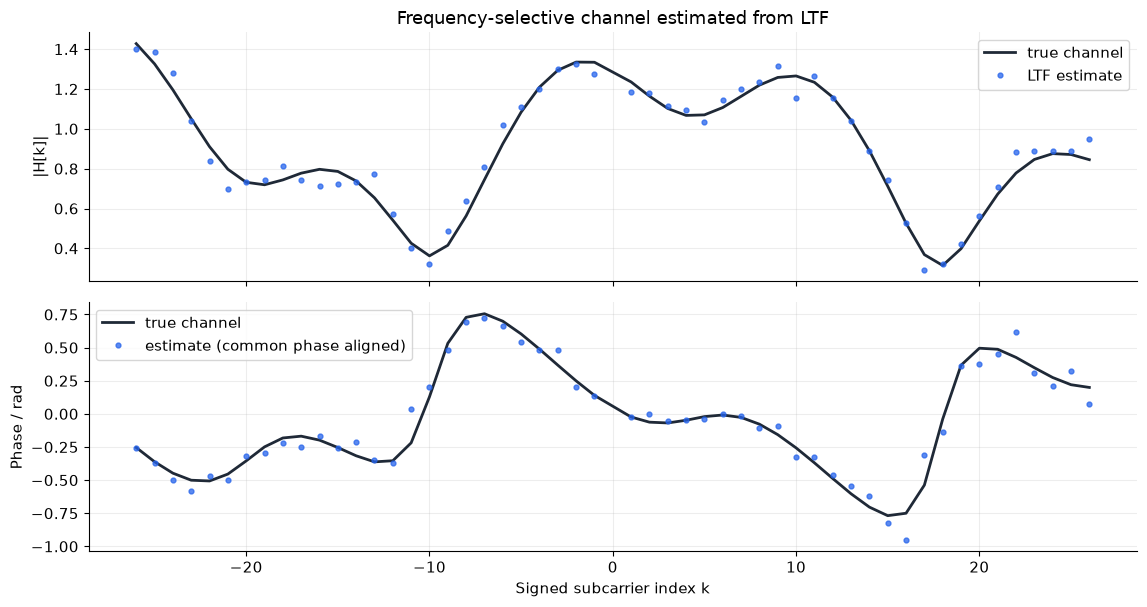

In [14]:
# Align to the detected STF start, then jump to the LTF field and remove its CP.
aligned = rx_cfo_corrected[timing_offset_hat:]
ltf_field_start = N_FFT
ltf_useful = aligned[ltf_field_start + N_CP:ltf_field_start + N_CP + N_FFT]
Y_ltf = ofdm_demodulate(ltf_useful)

H_hat = np.zeros(N_FFT, dtype=complex)
active_bins = sc_to_bin(active_sc, N_FFT)
H_hat[active_bins] = Y_ltf[active_bins] / frequency_grid[1, active_bins]
H_true = np.fft.fft(channel_taps, N_FFT)

order = np.argsort(active_sc)
active_sorted = active_sc[order]
active_bins_sorted = sc_to_bin(active_sorted, N_FFT)

fig, axes = plt.subplots(2, 1, figsize=(11.5, 6.2), sharex=True)
axes[0].plot(active_sorted, np.abs(H_true[active_bins_sorted]), color=INK, linewidth=2,
             label="true channel")
axes[0].plot(active_sorted, np.abs(H_hat[active_bins_sorted]), "o", markersize=3.5,
             color=BLUE, alpha=0.75, label="LTF estimate")
axes[0].set_title("Frequency-selective channel estimated from LTF")
axes[0].set_ylabel("|H[k]|")
axes[0].legend()

phase_alignment = np.angle(np.vdot(H_true[active_bins_sorted], H_hat[active_bins_sorted]))
axes[1].plot(active_sorted, np.unwrap(np.angle(H_true[active_bins_sorted])), color=INK, linewidth=2,
             label="true channel")
axes[1].plot(active_sorted,
             np.unwrap(np.angle(H_hat[active_bins_sorted] * np.exp(-1j * phase_alignment))),
             "o", markersize=3.5, color=BLUE, alpha=0.75, label="estimate (common phase aligned)")
axes[1].set_xlabel("Signed subcarrier index k")
axes[1].set_ylabel("Phase / rad")
axes[1].legend()
plt.tight_layout()
plt.show()

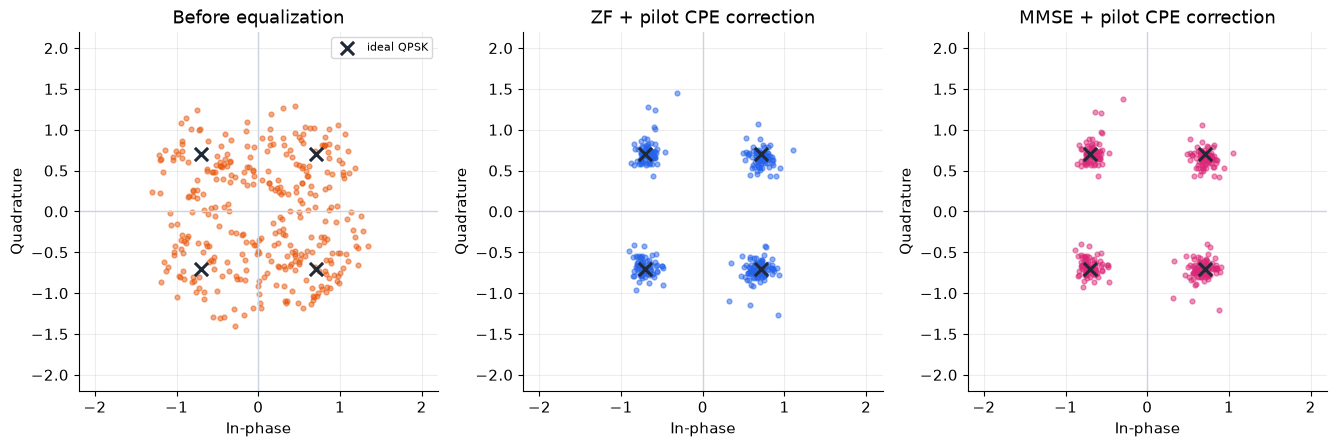

Estimated per-symbol CPE / rad: [0.039 0.217 0.16  0.261 0.289 0.337 0.42 ]
ZF:   RMS EVM = 15.97%, BER = 0.0000
MMSE: RMS EVM = 15.61%, BER = 0.0000


In [15]:
raw_data_symbols = []
zf_data_symbols = []
mmse_data_symbols = []
estimated_cpe = []

data_bins = sc_to_bin(data_sc, N_FFT)
pilot_bins = sc_to_bin(pilot_sc, N_FFT)

# With unitary FFT scaling, time-domain and frequency-domain noise variance are equal.
for grid_row in range(2, n_grid_symbols):
    field_start = N_FFT + (grid_row - 1) * (N_CP + N_FFT)
    useful = aligned[field_start + N_CP:field_start + N_CP + N_FFT]
    Y = ofdm_demodulate(useful)

    Z_zf = np.zeros(N_FFT, dtype=complex)
    Z_mmse = np.zeros(N_FFT, dtype=complex)
    Z_zf[active_bins] = Y[active_bins] / H_hat[active_bins]
    Z_mmse[active_bins] = (
        Y[active_bins] * np.conj(H_hat[active_bins])
        / (np.abs(H_hat[active_bins]) ** 2 + noise_variance)
    )

    # CPE is the phase of received pilots relative to their known values.
    cpe = np.angle(np.vdot(pilot_reference[grid_row - 2], Z_mmse[pilot_bins]))
    estimated_cpe.append(cpe)
    Z_zf *= np.exp(-1j * cpe)
    Z_mmse *= np.exp(-1j * cpe)

    raw_data_symbols.append(Y[data_bins])
    zf_data_symbols.append(Z_zf[data_bins])
    mmse_data_symbols.append(Z_mmse[data_bins])

raw_data_symbols = np.concatenate(raw_data_symbols)
zf_data_symbols = np.concatenate(zf_data_symbols)
mmse_data_symbols = np.concatenate(mmse_data_symbols)
tx_data_symbols = np.concatenate([
    frequency_grid[row, data_bins] for row in range(2, n_grid_symbols)
])

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.4))
plot_sets = [
    (raw_data_symbols, "Before equalization", ORANGE),
    (zf_data_symbols, "ZF + pilot CPE correction", BLUE),
    (mmse_data_symbols, "MMSE + pilot CPE correction", PINK),
]
for ax, (values, title, color) in zip(axes, plot_sets):
    ax.scatter(values.real, values.imag, s=12, alpha=0.5, color=color)
    draw_qpsk_reference(ax)
    ax.set_title(title)
    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
axes[0].legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

zf_evm = evm_rms(tx_data_symbols, zf_data_symbols)
mmse_evm = evm_rms(tx_data_symbols, mmse_data_symbols)
zf_ber = np.mean(qpsk_demod(zf_data_symbols) != tx_bits_all)
mmse_ber = np.mean(qpsk_demod(mmse_data_symbols) != tx_bits_all)

print("Estimated per-symbol CPE / rad:", np.round(estimated_cpe, 3))
print(f"ZF:   RMS EVM = {100 * zf_evm:.2f}%, BER = {zf_ber:.4f}")
print(f"MMSE: RMS EVM = {100 * mmse_evm:.2f}%, BER = {mmse_ber:.4f}")

## Checks

教学图容易“看起来对”，但还需要数值自检。下面检查本 Notebook 的关键不变量：STF 重复性、FFT 往返、同步误差、CFO 误差和最终 BER。若修改了 SNR、信道或同步方法，阈值也应相应调整。

In [16]:
checks = {
    "STF halves repeat": repeat_error < 1e-12,
    "IFFT/FFT round trip": np.max(np.abs(X_recovered - X_small)) < 1e-12,
    "timing within channel memory": abs(timing_offset_hat - timing_offset_true) <= len(channel_taps),
    "CFO error below 0.03 Δf": abs(cfo_hat - cfo_true) < 0.03,
    "final MMSE BER below 2%": mmse_ber < 0.02,
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL':4s}  {name}")

assert all(checks.values()), "At least one tutorial self-check failed. Inspect the cells above."
print("\nAll tutorial checks passed.")

PASS  STF halves repeat
PASS  IFFT/FFT round trip
PASS  timing within channel memory
PASS  CFO error below 0.03 Δf
PASS  final MMSE BER below 2%

All tutorial checks passed.


## Takeaways

1. OFDM 不是简单地“并排放很多频率”，而是在一个有限符号窗口内选择间隔 $1/T_u$ 的正交复指数基。
2. 多子载波叠加式就是 IDFT；IFFT 负责调制，FFT 负责解调。频域数组的每个元素就是一个 resource element。
3. 时频网格把训练、控制和数据统一成同一种复数资源：STF 用于捕获，LTF 用于信道估计，header/payload 中的 pilots 用于持续跟踪。
4. STF 的间隔子载波映射会在时域形成重复结构。Schmidl & Cox 同时利用其相关幅度做定时、利用相关相位做 CFO 估计。
5. CP 足够长时，多径信道在 FFT 后变成每个子载波上的复数增益，复杂的时域均衡问题就变成许多简单的单抽头均衡。

## Next Steps

可以在此基础上继续实验：

- 改变 `cfo_true`，观察超过 Schmidl & Cox 无模糊范围后的估计折叠；
- 把最大多径延迟改到超过 `N_CP`，观察 ISI/ICI 与星座劣化；
- 将 QPSK 替换为 16-QAM，比较相同 SNR 下的 EVM/BER；
- 用两个 LTF 做平均，并加入细定时与采样频偏（SFO）跟踪；
- 在 payload 上加入信道编码、交织和 CRC，形成更接近真实链路的 PHY。